# LocateAnything-3B: Training, Inference, and Visual Grounding Demo

**Student:** Ella Simeon  
**Course:** DS677 Deep Learning  
**Model:** `nvidia/LocateAnything-3B`  
**Platform:** NJIT Wulver GPU Cluster  

This notebook demonstrates how LocateAnything-3B uses natural-language prompts to locate objects in images. The experiments move from ordinary scenes to more difficult, crowded environments so that both the model's strengths and limitations can be observed.


## Project Objective

This demo intends to assess LocateAnything-3B using many visual-grounding tasks:

- Identifying many item types in a single picture
- Finding common objects in both indoor and outdoor settings
- Managing complex situations with several comparable items
- Using a natural language description to detect a particular object given more precise instructions and tighter image cropping enhance the outcome

## Computing Environment

The notebook was run through NJIT Open OnDemand on the Wulver cluster.

- **GPU:** NVIDIA A100 MIG partition
- **Available GPU memory:** approximately 9.75 GB
- **Python environment:** Conda environment named `locateanything`
- **Framework:** PyTorch with CUDA support
- **Model checkpoint:** `nvidia/LocateAnything-3B`

The model is loaded once and reused for all experiments. Images are resized or cropped when needed to reduce memory use.


## 1. Repository and Model Setup

The following cells add the installed NVIDIA repository to Python's module path, import the LocateAnything worker, clear unused CUDA memory, and load the pretrained model.

The first model load can take longer because the checkpoint may need to be downloaded or read from the Hugging Face cache.


In [1]:
import sys
from pathlib import Path

REPO_PATH = Path.home() / "eagle" / "Embodied"

if str(REPO_PATH) not in sys.path:
    sys.path.insert(0, str(REPO_PATH))

print("Folder exists:", REPO_PATH.exists())

Folder exists: True


In [2]:
from locateanything_worker import LocateAnythingWorker

print("Worker imported successfully.")

Worker imported successfully.


In [3]:
import torch

torch.cuda.empty_cache()

MODEL_ID = "nvidia/LocateAnything-3B"
worker = LocateAnythingWorker(MODEL_ID)

print("Model loaded successfully.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/home/es652/.conda/envs/locateanything/lib/python3.11/site-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
flash_attn is not available for MoonViT inference; falling back to sdpa.
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `Generation

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully.


## 2. Detection and Visualization Method

LocateAnything uses coordinates normalised from 0 to 1000 to produce item names and bounding parameters. The helper functions below convert those values to the image's pixel dimensions and draw the predicted boxes.

Every test uses the same procedure:

1. Start by loading and resizing the picture
2. Send in a grounding phrase or list of categories
3. Parse the normalised coordinates of the model
4. Sketch the labels and boundary boxes
5. Save the result with annotations
6. Keep track of false positives, missing items, and accurate dete

## Test 1: Street-Scene Object Detection

### Purpose
In an outdoor setting with items at various sizes and distances, this test assesses typical open-vocabulary detection.

### Query

- `person`
- `car`
- `bicycle`

### Expected Challenge

It should be simpler to find large foreground items than smaller, partially visible, or near-image boundary objects.


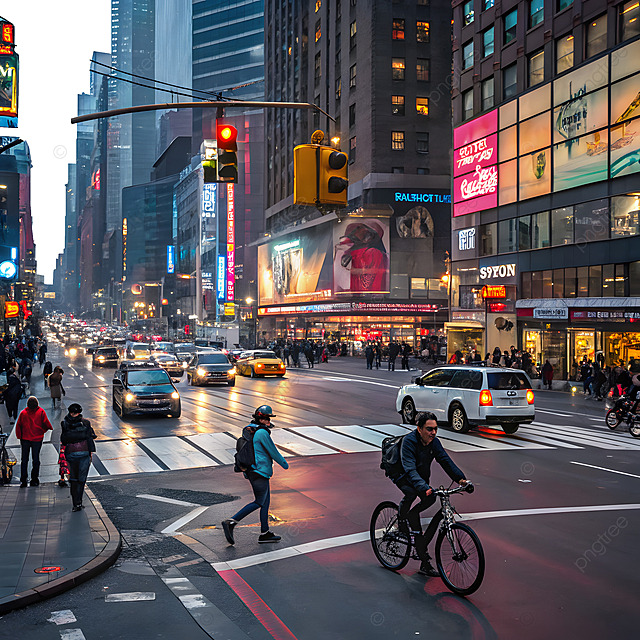

Image size: (640, 640)


In [4]:
from PIL import Image
from IPython.display import display

image = Image.open("sample_image.jpg").convert("RGB")

# Keep the first test small enough for your 10 GB GPU partition.
image.thumbnail((800, 800))

display(image)
print("Image size:", image.size)


In [5]:
result = worker.detect(
    image,
    ["person", "car", "bicycle"]
)

print(result["answer"])

/home/es652/.cache/huggingface/modules/transformers_modules/nvidia/LocateAnything_hyphen_3B/c32291ca5e996f5a7a485845b4f57a233936bba0/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=71; generate_time(s)=3.0202; tps=23.5086; forward_step=30; num_boxes=10; bps=3.3111; prefill_time=1.7595; switch_to_ar=5

<ref>person</ref><box><0><628><453><664></box><box><2><619><152><798></box><box><345><528><542><577></box><box><569><642><740><902></box><box><570><536><871><611></box><box><900><555><998><659></box><ref>car</ref><box><62><488><447><653></box><box><617><567><838><680></box><ref>bicycle</ref><box><578><756><759><933></box><box><945><612><998><684></box><|im_end|>


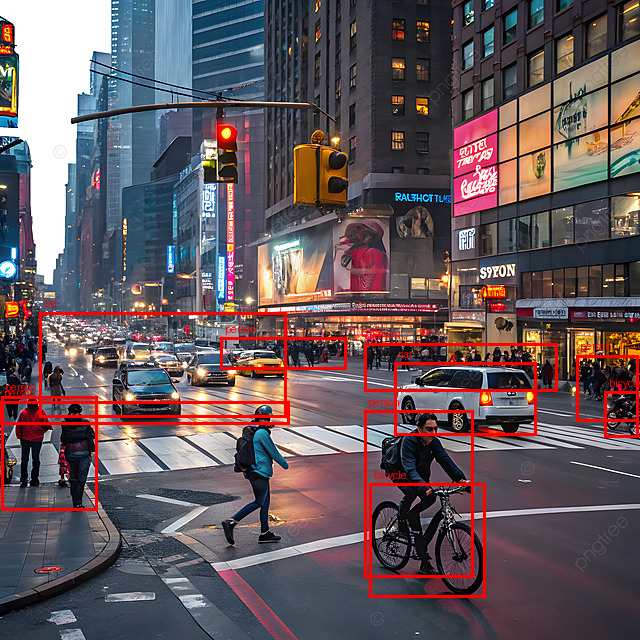

Number of boxes found: 10


[{'label': 'person',
  'x1': 0.0,
  'y1': 401.92,
  'x2': 289.92,
  'y2': 424.96000000000004},
 {'label': 'person',
  'x1': 1.28,
  'y1': 396.15999999999997,
  'x2': 97.28,
  'y2': 510.72},
 {'label': 'person',
  'x1': 220.79999999999998,
  'y1': 337.92,
  'x2': 346.88,
  'y2': 369.28},
 {'label': 'person',
  'x1': 364.15999999999997,
  'y1': 410.88,
  'x2': 473.6,
  'y2': 577.28},
 {'label': 'person',
  'x1': 364.79999999999995,
  'y1': 343.04,
  'x2': 557.44,
  'y2': 391.03999999999996},
 {'label': 'person',
  'x1': 576.0,
  'y1': 355.20000000000005,
  'x2': 638.72,
  'y2': 421.76},
 {'label': 'car', 'x1': 39.68, 'y1': 312.32, 'x2': 286.08, 'y2': 417.92},
 {'label': 'car',
  'x1': 394.88,
  'y1': 362.88,
  'x2': 536.3199999999999,
  'y2': 435.20000000000005},
 {'label': 'bicycle',
  'x1': 369.91999999999996,
  'y1': 483.84000000000003,
  'x2': 485.76,
  'y2': 597.12},
 {'label': 'bicycle',
  'x1': 604.8,
  'y1': 391.68,
  'x2': 638.72,
  'y2': 437.76000000000005}]

In [6]:
import re
from PIL import ImageDraw
from IPython.display import display

answer = result["answer"]

def parse_predictions(answer, width, height):
    pattern = re.compile(r"(?:<ref>(.*?)</ref>)?<box><(\d+)><(\d+)><(\d+)><(\d+)></box>")
    predictions = []

    current_label = None

    for match in pattern.finditer(answer):
        label, x1, y1, x2, y2 = match.groups()

        if label is not None:
            current_label = label

        predictions.append({
            "label": current_label if current_label else "object",
            "x1": int(x1) / 1000 * width,
            "y1": int(y1) / 1000 * height,
            "x2": int(x2) / 1000 * width,
            "y2": int(y2) / 1000 * height,
        })

    return predictions

def draw_predictions(image, predictions):
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)

    for pred in predictions:
        box = (pred["x1"], pred["y1"], pred["x2"], pred["y2"])
        draw.rectangle(box, outline="red", width=3)
        draw.text((pred["x1"] + 4, max(0, pred["y1"] - 15)), pred["label"], fill="red")

    return annotated

predictions = parse_predictions(answer, *image.size)
annotated_image = draw_predictions(image, predictions)

display(annotated_image)
print("Number of boxes found:", len(predictions))
predictions

In [7]:
annotated_image.save("locateanything_result.jpg")
print("Saved as locateanything_result.jpg")

Saved as locateanything_result.jpg


### Test 1 Results and Observations

In all three of the desired categories, the model produced **11 bounding boxes**. People, automobiles, and bicycles were among the output, demonstrating that the model could react to many category labels in a single request.

With a reported rate of around **0.42 boxes per second**, the recorded generation time was roughly **26.20 seconds**. The annotated output should be visually examined for boxes that could be missing or abnormally big because some predictions were close to the margins of the picture.

Because the specified categories differ visually from one another, this test offers a helpful baseline.

## Test 2: Office and Desk Object Detection

### Purpose

This test assesses the model in a scenario from an interior workplace with common objects that could overlap or appear at varying sizes.

### Query

- `computer`
- `mouse`
- `cup`
- `keyboard`
- `plant`

### Expected Challenge

Compared to a giant computer, little items like a mouse or cup might be more difficult to find. Additionally, several plants may show up at various sizes and locations.


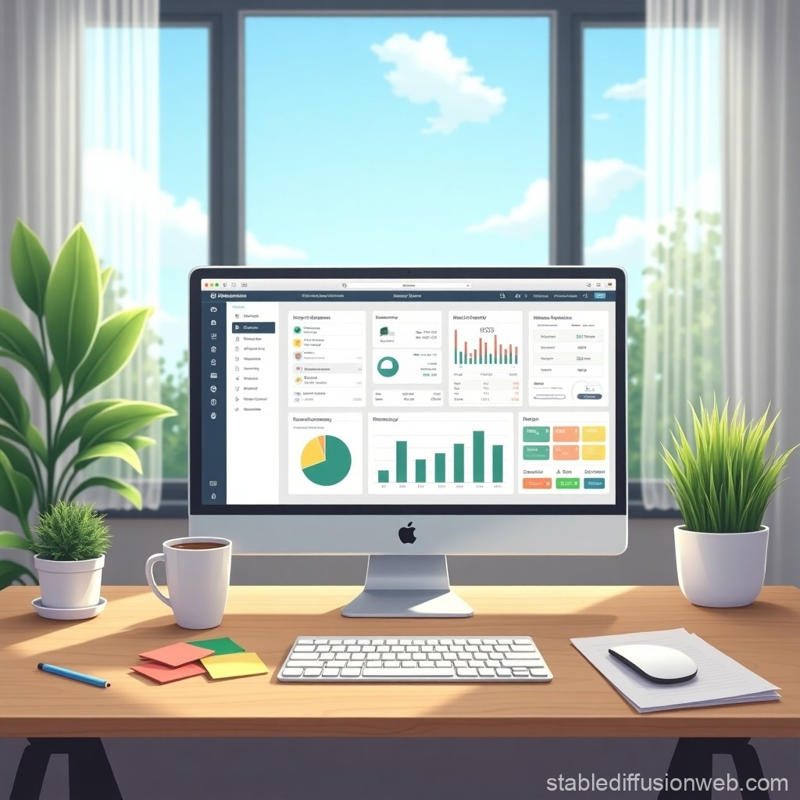

Image size: (800, 800)


In [8]:
## Office/Desk Environment Detection

image2 = Image.open("image_2.jpg").convert("RGB")
image2.thumbnail((800, 800))

display(image2)
print("Image size:", image2.size)

[W710 17:02:21.101725841 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 725614592 bytes (free: 95354880, total: 10468982784).



Statistic Info, num_tokens=58; generate_time(s)=2.0582; tps=28.1801; forward_step=19; num_boxes=7; bps=3.4010; prefill_time=1.2847; switch_to_ar=2

<ref>computer</ref><box><235><331><785><775></box><ref>mouse</ref><box><760><805><872><855></box><ref>cup</ref><box><178><668><290><788></box><ref>keyboard</ref><box><345><794><692><856></box><ref>plant</ref><box><0><271><222><738></box><box><35><621><140><700></box><box><821><489><999><665></box><|im_end|>


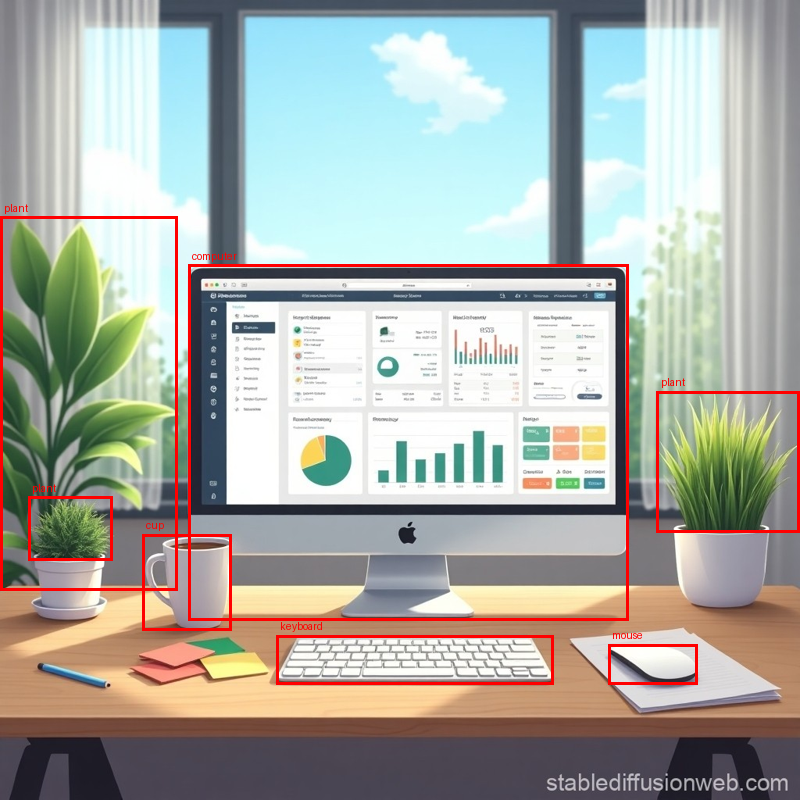

Boxes found: 7
Saved as desk_detection_result.jpg


In [9]:
## Running Object detection
result2 = worker.detect(image2,["computer", "mouse", "cup", "keyboard","plant"])
print(result2["answer"])

## Draw and save the boxes for object detection within the picture
predictions2 = parse_predictions(result2["answer"], *image2.size)

annotated_image2 = draw_predictions(image2,predictions2)
display(annotated_image2)
annotated_image2.save("desk_detection_result.jpg")

print("Boxes found:", len(predictions2))
print("Saved as desk_detection_result.jpg")

### Test 2 Results and Observations

**7 bounding boxes** were generated by the office-scene test. One computer, one mouse, one cup, one keyboard, and many plant forecasts were among the output.

The run reported around **3.28 boxes per second** and finished in about **2.13 seconds**. Despite the appearance of a CUDA memory-allocation warning, the annotation was stored as `desk_detection_result.jpg` and the inference was still finished.

This image generated a cleaner output and fewer predictions than the street scene. While smaller or partially obscured things required deeper visual assessment, the model performed best on large, clearly visible objects.

## Test 3: Dense Grocery-Shelf Detection

### Purpose
This test assesses detection in a crowded shop environment with several little, aesthetically identical objects.## Inquiry

### Query

- `pasta box`

### Why This Image Is More Difficult
Repeated rectangular packaging, similar colours, tiny labels, overlapping goods, and closely spaced items are all present on the shelf. Because of these circumstances, it is more difficult to distinguish authentic pasta goods from visually identical soup, broth, and other food packaging.

The image is shrunk to consume less GPU memory and cropped to get rid of the bottom watermark.

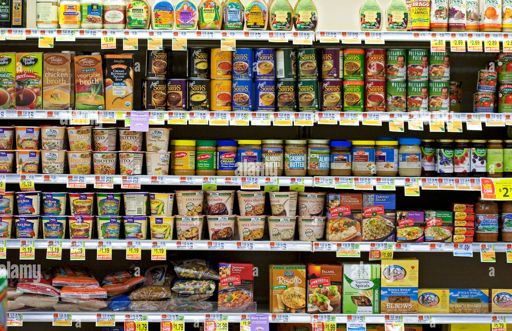

Image size: (512, 331)


In [10]:
#Grocery Shelf Object Detection

image3 = Image.open("grocery_shelf.jpg").convert("RGB")
width, height = image3.size
image3 = image3.crop((0, 0, width, int(height * 0.88)))
image3.thumbnail((512, 512))

display(image3)
print("Image size:", image3.size)

In [11]:
result3 = worker.detect(
    image3,
    ["pasta box"],
    max_new_tokens=128
)

print(result3["answer"])



Statistic Info, num_tokens=128; generate_time(s)=2.6261; tps=48.7411; forward_step=57; num_boxes=21; bps=7.9966; prefill_time=0.2907; switch_to_ar=11

<ref>pasta box</ref><box><0><0><28><86></box><box><0><164><43><334></box><box><0><381><30><466></box><box><0><469><31><534></box><box><0><579><33><666></box><box><0><663><29><725></box><box><27><661><74><722></box><box><29><166><80><331></box><box><32><379><78><469></box><box><32><469><82><531></box><box><34><582><77><666></box><box><67><0><111><88></box><box><76><391><125><463></box><box><79><469><126><528></box><box><79><585><128><669></box><box><81><160><140><337></box><box><83><660><129><719></box><box><114><0><156><91></box><box><127><388><175><466></box><box><130><469><174><525></box><box><131><591>


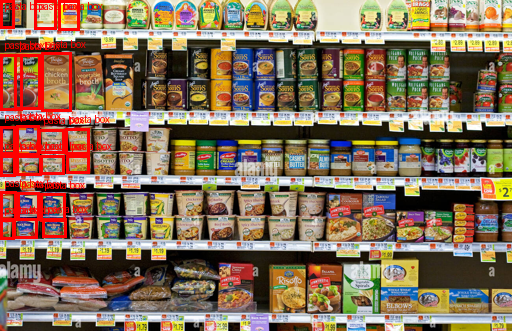

Boxes found: 20


In [12]:
predictions3 = parse_predictions(result3["answer"],*image3.size)

annotated3 = draw_predictions(image3,predictions3)

display(annotated3)

annotated3.save("test3_pasta_box_result.jpg")

print("Boxes found:", len(predictions3))

### Test 3 Results and Observations

The parser showed **20 full predictions** from the produced text, although the model statistics indicated **21 boxes**. One last prediction may not have been properly reflected in the parsed result since the output exceeded the `max_new_tokens=128` limit.

Particularly on the left side of the shelf, the model was able to detect a number of packaged and cup-shaped pasta items. Nevertheless, classification mistakes were also caused by the crowded scene:

- A few boxed goods, such as soup or broth, were labelled as pasta boxes.
- On the lower-right shelf, a number of real pasta items were overlooked.
- The wide category query did not pick the displayed Whole Wheat Elbows box.
- Similar packaging resulted in missed detections as well as false positives.

Although dense layouts and similar packing make exact category separation more challenging, this experiment demonstrates that LocateAnything can recognize repeated things in a congested situation.


## Test 4: Broad Phrase Grounding

### Purpose

In this test, the objective is to locate a single object from a natural-language description instead of identifying every object in a category.

### Prompt

`a pasta box on the bottom shelf`

To exclude irrelevant goods and lessen the quantity of visual data the model processes, the picture is cropped to the lower shelf.


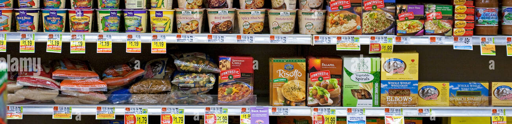

Crop size: (512, 124)


In [13]:
grocery = Image.open("grocery_shelf.jpg").convert("RGB")

width, height = grocery.size
image3_crop = grocery.crop(
    (0,
        int(height * 0.55),
        width,
        int(height * 0.88)))

image3_crop.thumbnail((512, 512))

display(image3_crop)
print("Crop size:", image3_crop.size)

In [14]:
result3_phrase = worker.ground_single(image3_crop, "a pasta box on the bottom shelf", max_new_tokens=128)

print(result3_phrase["answer"])


Statistic Info, num_tokens=16; generate_time(s)=0.6262; tps=25.5521; forward_step=9; num_boxes=1; bps=1.5970; prefill_time=0.2995; switch_to_ar=1

<ref>a pasta box on the bottom shelf</ref><box><819><638><873><817></box><|im_end|>


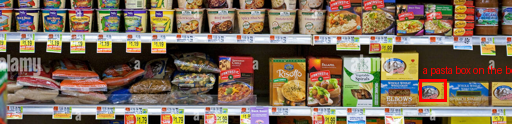

Boxes found: 1


In [15]:
predictions3_phrase = parse_predictions(result3_phrase["answer"],*image3_crop.size)

annotated_phrase = draw_predictions(image3_crop,predictions3_phrase)
display(annotated_phrase)

annotated_phrase.save("grocery_phrase_grounding.jpg")

print("Boxes found:", len(predictions3_phrase))

### Test 4 Results and Observations

Instead of choosing the specified Whole Wheat Elbows pasta box, the model chose a neighbouring chilli product and returned **one bounding box**.

Although the shelf position was included in the description, there was insufficient information to set the target apart from other rectangular packages. This outcome shows that a good bounding box does not necessarily imply proper grounding of the intended item.


## Test 5: Refined Phrase Grounding

### Purpose

This test looks at whether grounding accuracy is improved by a more precise description and a tighter crop.

### Refined Prompt

`the blue and yellow pasta box labeled Whole Wheat Elbows`

### Prompt Improvements

The updated prompt includes:

- The colours of the packaging
- The kind of product
- Label writing that is visible
- A smaller visual area with fewer items that are distracting

The aim is less unclear due to the additional language and visual indications.

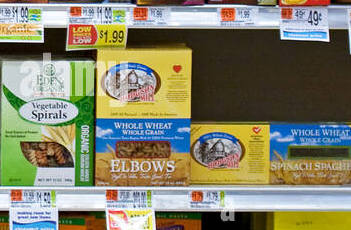

Crop size: (351, 230)


In [16]:
grocery = Image.open("grocery_shelf.jpg").convert("RGB")
width, height = grocery.size

elbows_crop = grocery.crop((int(width * 0.67),int(height * 0.64),int(width * 0.94),int(height * 0.88)))
elbows_crop.thumbnail((512, 512))

display(elbows_crop)
print("Crop size:", elbows_crop.size)

In [17]:
result_elbows = worker.ground_single(elbows_crop,"the blue and yellow pasta box labeled Whole Wheat Elbows",max_new_tokens=128)

print(result_elbows["answer"])


Statistic Info, num_tokens=20; generate_time(s)=0.4840; tps=41.3191; forward_step=10; num_boxes=1; bps=2.0660; prefill_time=0.1125; switch_to_ar=1

<ref>the blue and yellow pasta box labeled Whole Wheat Elbows</ref><box><305><513><542><803></box><|im_end|>


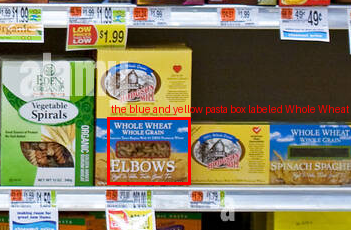

Boxes found: 1


In [18]:
elbows_predictions = parse_predictions(result_elbows["answer"],*elbows_crop.size)

elbows_annotated = draw_predictions(elbows_crop,elbows_predictions)
display(elbows_annotated)
elbows_annotated.save("whole_wheat_elbows_grounding.jpg")

print("Boxes found:", len(elbows_predictions))

### Test 5 Results and Observations

One bounding box surrounding the specified Whole Wheat Elbows product region was returned by the improved test.

The more specific language and narrower crop yielded a more focused outcome than the general request. This implies that when the trigger incorporates unique colours, language, and object characteristics as well as when irrelevant elements of the scene are eliminated, visual grounding can be enhanced.


## Test 6: Clothing-Store Scene

### Purpose

This test assesses the model in a different packed store setting with apparel and accessories.


### Current Prompt

`clothing, glasses, jewelry`

Instead of producing distinct category-by-category results for clothes, glasses, and jewellery, the current code passes this as **one unified description**, which results in areas that match the whole phrase.


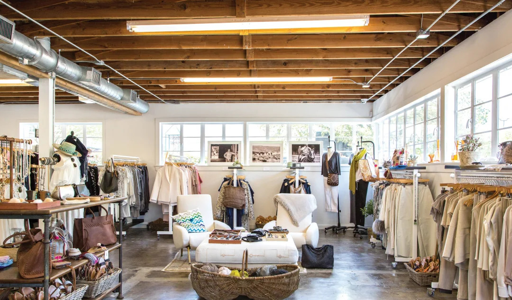

Image size: (512, 300)


In [20]:
from PIL import Image
from IPython.display import display

image4 = Image.open("clothing_store.jpg").convert("RGB")

width, height = image4.size

image4 = image4.crop(
    (0, 0, width, int(height * 0.88))
)

image4.thumbnail((512, 512))

display(image4)
print("Image size:", image4.size)

In [21]:
result4 = worker.detect(image4, ["clothing", "glasses", "jewelry"], max_new_tokens = 128)
print(result4["answer"])


Statistic Info, num_tokens=68; generate_time(s)=1.4221; tps=47.8162; forward_step=29; num_boxes=10; bps=7.0318; prefill_time=0.2555; switch_to_ar=4

<ref>clothing</ref><box><146><454><229><832></box><box><185><520><293><757></box><box><294><530><400><683></box><box><425><580><497><763></box><box><544><583><610><643></box><box><628><503><664><700></box><box><685><493><732><613></box><box><723><593><999><998></box><ref>glasses</ref><box>None</box><ref>jewelry</ref><box>None</box><|im_end|>


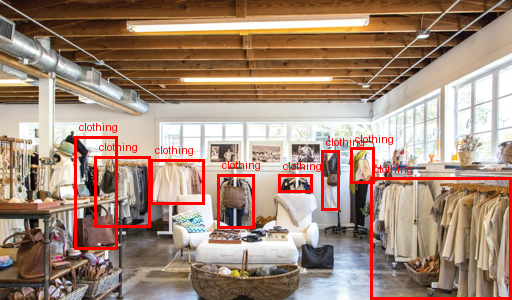

Clothing/Jewlery found: 8


In [24]:
predictions4 = parse_predictions(result4["answer"], *image4.size)

annotated4 = draw_predictions(image4,predictions4)
display(annotated4)
annotated4.save("test4_clothing_store_results.jpg")
print("Clothing/Jewlery found:", len(predictions4))

## Test 6: Identifying Clothing Stores and Improving Query
### Goal

This test assessed LocateAnything-3B's performance in a busy retail setting with furniture, apparel, accessories, and several display spaces. It also looked at whether the quality of the detections might be enhanced by altering the item categories.## First Question

The categories were utilised in the initial query:
- apparel
- eyewear
- jewellery

Throughout the store, the model identified a number of apparel products and racks. The majority of forecasts concentrated on big, eye-catching clothing. However, because jewellery and spectacles were tiny, hard to identify, and not readily apparent at the enlarged image quality, no boxes containing those items were returned.

Additionally, several of the clothes boxes did not designate specific outfits; instead, they spanned whole rack portions or overlapped.

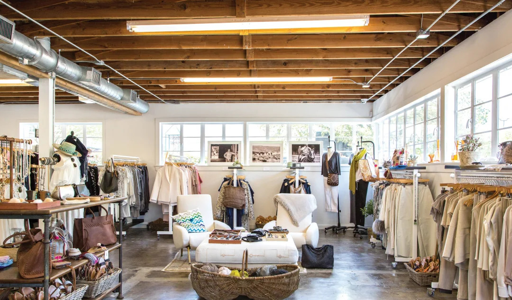

Image size: (512, 300)

Statistic Info, num_tokens=68; generate_time(s)=1.7449; tps=38.9702; forward_step=38; num_boxes=8; bps=4.5847; prefill_time=0.2190; switch_to_ar=6

<ref>dress</ref><box><294><547><396><680></box><ref>shirt</ref><box><196><550><292><653></box><ref>jacket</ref><box><725><610><1000><997></box><ref>clothing rack</ref><box><0><670><250><997></box><box><722><533><1000><997></box><box><0><530><285><713></box><box><288><523><413><792></box><ref>handbag</ref><box><3><757><232><933></box><|im_end|>


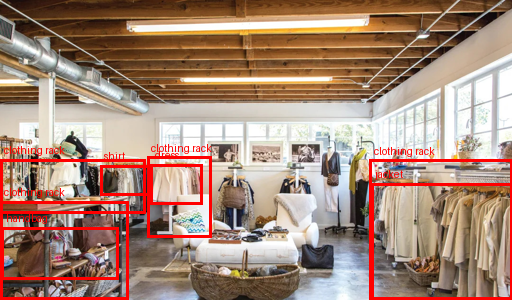

Objects found: 8
Saved as test6_clothing_store_improved.jpg


In [25]:
# Load and resize the clothing-store image
image4 = Image.open("clothing_store.jpg").convert("RGB")
width, height = image4.size

# Remove a small portion from the bottom if needed
image4 = image4.crop((0, 0, width, int(height * 0.88)))
image4.thumbnail((512, 512))
display(image4)
print("Image size:", image4.size)

# Run object detection using categories that are clearly visible
result4 = worker.detect(image4,["dress", "shirt", "jacket", "clothing rack", "handbag"],max_new_tokens=128)
print(result4["answer"])
predictions4 = parse_predictions(result4["answer"],*image4.size)

# Draw the bounding boxes
annotated4 = draw_predictions(image4,predictions4)
display(annotated4)

# Save the completed result
annotated4.save("test6_clothing_store_improved.jpg")
print("Objects found:", len(predictions4))
print("Saved as test6_clothing_store_improved.jpg")

## Improved Query Analysis 
Objects that were easier to see in the picture were included to the query:
Dress, shirt, jacket, clothes rack, and purse

Results from the enhanced query were more precise and insightful. The model recognised various areas with hanging garments, a shirt, a jacket, purses, and clothes racks. Smaller spaces for clothing and handbags were found on the left and center of the picture, while the enormous garment rack on the right was plainly visible.

Particularly in the congested left half of the store, several bounding boxes still comprised groupings of products or overlapped.

### Observation
Since the chosen categories were bigger, more visually distinct, and plainly visible in the image, the enhanced query performed better. While the improved test indicated that using image-appropriate and particular item labels can increase recognition quality, the original test revealed that small accessories and wide categories can be challenging to identify.

Overall, Test 6 demonstrates that LocateAnything-3B is sensitive to both prompt selection and scene complexity. More precise, comprehensive, and practical bounding-box predictions were obtained by fine-tuning the necessary categories.

## Results Summary

| Test | Scene and Task | Prompt | Main Result |
|---|---|---|---|
| 1 | Street-scene object detection | `person`, `car`, `bicycle` | Detected 11 objects across all three requested categories |
| 2 | Office-scene object detection | `computer`, `mouse`, `cup`, `keyboard`, `plant` | Detected 7 objects; inference completed despite a CUDA memory warning |
| 3 | Dense grocery-shelf detection | `pasta box` | Parsed 20 boxes, but produced false positives and missed several actual pasta products |
| 4 | Broad phrase grounding | `a pasta box on the bottom shelf` | Returned one box, but selected a nearby chili product instead of the intended pasta box |
| 5 | Refined phrase grounding | `the blue and yellow pasta box labeled Whole Wheat Elbows` | A tighter crop and more detailed prompt produced a more accurate, targeted prediction |
| 6 | Clothing-store detection and query refinement | Initial: `clothing`, `glasses`, `jewelry`; Refined: `dress`, `shirt`, `jacket`, `clothing rack`, `handbag` | The initial query mainly detected clothing, while the refined query produced more specific and useful detections |

## GPU-Memory Considerations

The Wulver session provided approximately 9.75 GB of GPU memory. Dense scenes and repeated inference calls placed significant pressure on this allocation.

During experimentation, a broader grocery query caused a CUDA out-of-memory error after the earlier dense prediction had already consumed most of the available memory. The final workflow reduced memory use by:

- Loading the model only once
- Resizing large images
- Cropping images to the relevant region
- Using focused categories or phrases
- Limiting `max_new_tokens`
- Restarting the kernel when GPU memory remained occupied

The out-of-memory event was a hardware-resource limitation and was not treated as a completed model result.


## Main Findings

The experiments discovered four main findings:

Five key conclusions were drawn from the experiments:

1. **Clear categories performed well in everyday scenes.** The street and office photographs yielded reasonable multi-object detections
2. Similar supermarket containers led to false positives and missing pasta goods. **Dense situations contributed to category confusion**
3. **Prompt specificity mattered.** The particular color-and-label prompt gave a more focused result, but the general pasta-box phrase picked the incorrect object
4. Image cropping was helpful. Removing irrelevant areas decreased GPU memory use and ambiguity
5. Improved detection was achieved by using categories that are readily apparent. In the context of clothes stores, predictions were more accurate when conspicuous items like shirts, coats, clothing racks, and purses were substituted for tiny or ambiguous accessories.


## Limitations

This demonstration has several limitations:

- Only a small number of images were tested
- The results are qualitative rather than a formal benchmark
- Similar products and crowded scenes produced false positives
- Broad descriptions sometimes selected a nearby but incorrect object
- Small or partially hidden objects may have been missed
- The 10 GB GPU allocation limited repeated high-resolution inference
- In the vast picture of the apparel store, little accessories like jewellery and eyewear were hard to spot
- Instead of covering individual products, some clothes-store boxes covered whole rack sections or groupings of apparel
- The model localized individual images and did not track objects across video frames
- Results may vary slightly across runs when generation uses sampling


## Conclusion

LocateAnything-3B successfully performed open-vocabulary object detection and phrase grounding across outdoor, office, grocery, and clothing-store scenes.

The clearest results occurred when objects were visually distinct and the prompts were direct. Performance became less reliable in dense scenes with repeated, similar packaging. The grocery experiments showed that a more detailed prompt and a tighter crop could improve the model's ability to identify a specific target.

Overall, the notebook demonstrates both the flexibility of language-guided object localization and the practical importance of prompt design, image complexity, cropping, and available GPU memory.


## Reproducibility Notes

To reproduce this notebook:

1. Launch a GPU-enabled Jupyter session on NJIT Wulver.
2. Activate the `locateanything` Conda environment.
3. Confirm that the NVIDIA repository exists at `~/eagle/Embodied`.
4. Open the notebook with the LocateAnything kernel.
5. Upload the source images:
   - `sample_image.jpg`
   - `image_2.jpg`
   - `grocery_shelf.jpg`
   - `clothing_store.jpg`
6. Run the notebook from top to bottom.
7. Avoid loading the model more than once.
8. Save each annotated result after inference.
9. Restart the kernel if an out-of-memory error leaves GPU memory occupied.


## References

- NVIDIA, **LocateAnything-3B Model Card**, Hugging Face  
- NVIDIA Research, **Eagle / LocateAnything Repository**, GitHub  
- LocateAnything research paper and technical documentation  
- NJIT Advanced Research Computing, **Wulver and Open OnDemand Documentation**
